# Hybrid CNN + GRU — battery SOH prediction

Combines per-step CNN encoding (the architecture that wins single-step k-fold) with a small bidirectional GRU that aggregates W=10 block embeddings. Each block contributes K=32 raw 301-step samples; the CNN encoder is shared across all (W·K) steps and produces a 128-dim embedding; embeddings are mean-pooled within each block before the GRU.

**Why hybrid?** Experiment A established that within-step temporal order carries zero signal for SOH (per-block label, R²=1.0 by block identity). Cycle-history reframing lifted LSTM 10.88% → 8.24%. The hybrid replaces hand-crafted block features with a learned CNN encoder over raw steps, giving the GRU much richer per-block embeddings.

**Why GRU not LSTM?** Sequence length is only 10 blocks. GRU has ~25% fewer parameters than LSTM at the same hidden size, trains faster, and is empirically better on short sequences with small training sets — both of which apply here (~260 training sequences).

In [1]:
import math
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.dataset_hybrid import HybridDataset
from src.models.hybrid import SOHHybrid
from src.utils import set_all_seeds

H5_PATH    = '../data/processed/sequences.h5'
CKPT_DIR   = '../checkpoints'
FIG_DIR    = '../results/figures'
WINDOW     = 10
K_STEPS    = 32

LR           = 5e-4
WEIGHT_DECAY = 1e-4
BATCH_SIZE   = 16
MAX_EPOCHS   = 100
PATIENCE     = 15
SEED         = 42
CLIP_GRAD    = 1.0

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
set_all_seeds(SEED)
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
print(f'PyTorch {torch.__version__}  |  Device: {DEVICE}')

PyTorch 2.7.1+cu118  |  Device: cuda


In [2]:
# Preload full X into RAM once (~1.52 GB) — skips HDF5 reads during training.
X_mem = HybridDataset.preload_X(H5_PATH)
print(f'Preloaded X: {X_mem.shape}  ({X_mem.nbytes / 1024**3:.2f} GB)')

# Build datasets. Train uses random step sampling per epoch (data aug);
# val/test use deterministic=True so the same K steps are drawn each call.
train_ds = HybridDataset(H5_PATH, window=WINDOW, k_steps=K_STEPS, split='train',
                          preloaded_X=X_mem)
val_ds   = HybridDataset(H5_PATH, window=WINDOW, k_steps=K_STEPS, split='val',
                          norm_mean=train_ds.norm_mean, norm_std=train_ds.norm_std,
                          deterministic=True, preloaded_X=X_mem)
test_ds  = HybridDataset(H5_PATH, window=WINDOW, k_steps=K_STEPS, split='test',
                          norm_mean=train_ds.norm_mean, norm_std=train_ds.norm_std,
                          deterministic=True, preloaded_X=X_mem)

print('=== Train ==='); train_ds.describe(); print()
print('=== Val   ==='); val_ds.describe(); print()
print('=== Test  ==='); test_ds.describe(); print()

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f'Train batches/epoch: {len(train_loader)}')

Preloaded X: (450526, 301, 3)  (1.52 GB)
=== Train ===
Split: train  |  Sequences: 259  |  W=10, K=32
SOH range: 33.1% – 84.4%  (mean 63.1%)
Sample shape: (10, 32, 301, 3)

=== Val   ===
Split: val  |  Sequences: 45  |  W=10, K=32
SOH range: 35.7% – 77.8%  (mean 54.0%)
Sample shape: (10, 32, 301, 3)

=== Test  ===
Split: test  |  Sequences: 38  |  W=10, K=32
SOH range: 41.6% – 86.6%  (mean 63.6%)
Sample shape: (10, 32, 301, 3)

Train batches/epoch: 17


In [3]:
model = SOHHybrid(window=WINDOW, k_steps=K_STEPS).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'SOHHybrid(W={WINDOW}, K={K_STEPS})  —  {n_params:,} parameters')
print(model)

# Forward-pass shape check
with torch.no_grad():
    xb, _ = next(iter(val_loader))
    print(f'\nInput batch:  {tuple(xb.shape)}')
    out = model(xb.to(DEVICE))
    print(f'Output:       {tuple(out.shape)}')

SOHHybrid(W=10, K=32)  —  168,161 parameters
SOHHybrid(
  (encoder): CNNStepEncoder(
    (conv1): Sequential(
      (0): Conv1d(3, 32, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv2): Sequential(
      (0): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv3): Sequential(
      (0): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (pool3): MaxPool1d(kernel_siz

In [4]:
def evaluate(loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds.append(model(xb.to(DEVICE)).squeeze(1).cpu())
            targets.append(yb)
    p = torch.cat(preds)   * 100.0
    t = torch.cat(targets) * 100.0
    mae  = (p - t).abs().mean().item()
    rmse = math.sqrt(((p - t) ** 2).mean().item())
    return mae, rmse, p.numpy(), t.numpy()

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5, min_lr=1e-6)
criterion = nn.MSELoss()

ckpt_path = os.path.join(CKPT_DIR, 'SOHHybrid_best.pt')
history = {'train_loss': [], 'val_mae': [], 'val_rmse': [], 'test_mae': [], 'test_rmse': [], 'lr': []}
best_val_mae = float('inf')
no_improve = 0

print(f'{"Epoch":>6}  {"TrainLoss":>10}  {"ValMAE%":>9}  {"ValRMSE%":>10}  {"TestMAE%":>10}  {"LR":>9}  {"Time":>5}')
print('-' * 84)

for epoch in range(1, MAX_EPOCHS + 1):
    t0 = time.time()
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(xb).squeeze(1), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
        optimizer.step()
        running += loss.item()
    train_loss = running / len(train_loader)

    val_mae, val_rmse, _, _   = evaluate(val_loader)
    test_mae, test_rmse, _, _ = evaluate(test_loader)
    scheduler.step(val_mae)
    lr_now = optimizer.param_groups[0]['lr']
    elapsed = time.time() - t0

    history['train_loss'].append(train_loss)
    history['val_mae'].append(val_mae)
    history['val_rmse'].append(val_rmse)
    history['test_mae'].append(test_mae)
    history['test_rmse'].append(test_rmse)
    history['lr'].append(lr_now)

    flag = ''
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        no_improve = 0
        torch.save({'epoch': epoch, 'val_mae': val_mae,
                    'model_state_dict': model.state_dict()}, ckpt_path)
        flag = ' ✓'
    else:
        no_improve += 1
    print(f'{epoch:>6}  {train_loss:>10.6f}  {val_mae:>9.4f}  {val_rmse:>10.4f}  {test_mae:>10.4f}  {lr_now:>9.2e}  {elapsed:>4.1f}s{flag}')
    if no_improve >= PATIENCE:
        print(f'Early stop at epoch {epoch} (no val improvement for {PATIENCE} epochs)')
        break

print(f'\nBest val MAE: {best_val_mae:.4f}%   (checkpoint: {ckpt_path})')

 Epoch   TrainLoss    ValMAE%    ValRMSE%    TestMAE%         LR   Time
------------------------------------------------------------------------------------
     1    0.111217    26.9156     28.2558     35.8503   5.00e-04   1.8s ✓
     2    0.034423     7.1803      8.9132     13.8044   5.00e-04   1.6s ✓
     3    0.028950     7.4607      9.3372     13.2847   5.00e-04   1.7s
     4    0.021214     9.5771     11.5879     13.6753   5.00e-04   1.7s
     5    0.017527     6.5108      8.1239     12.0645   5.00e-04   1.7s ✓
     6    0.019871     8.0092     10.0704     14.2957   5.00e-04   1.7s
     7    0.016668    10.2298     11.8668     12.8859   5.00e-04   1.7s
     8    0.014302    11.1880     12.7768     14.6585   5.00e-04   1.7s
     9    0.019219    11.3335     12.7342     14.6533   5.00e-04   1.7s
    10    0.016654     6.8133      8.7348     12.9965   5.00e-04   1.7s
    11    0.016032     5.6962      7.3572     12.5151   5.00e-04   1.6s ✓
    12    0.015795     4.6077      6.1714  

In [5]:
# Load best checkpoint and report final test metrics
ckpt = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

test_mae, test_rmse, preds, targets = evaluate(test_loader)
print(f'Best epoch: {ckpt["epoch"]}')
print(f'Test MAE:  {test_mae:.4f}%')
print(f'Test RMSE: {test_rmse:.4f}%')

Best epoch: 25
Test MAE:  11.6294%
Test RMSE: 15.8437%


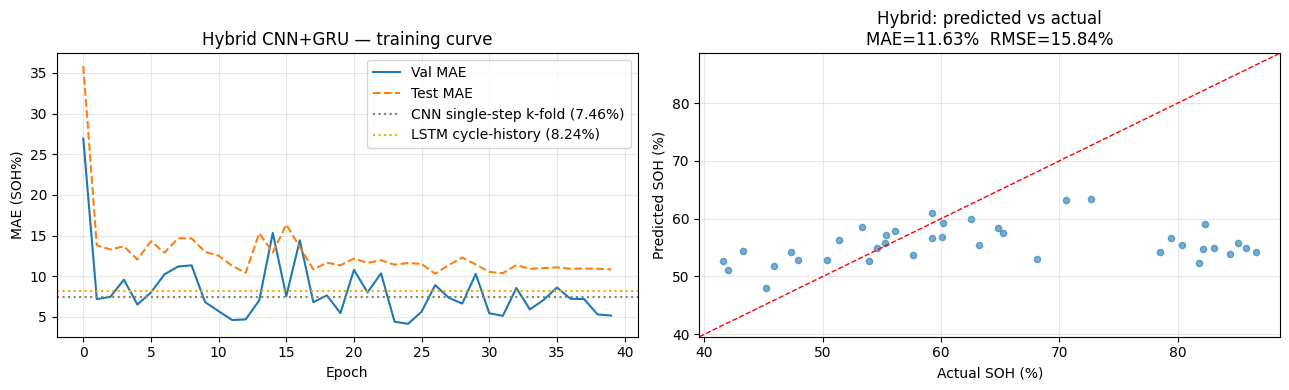

In [6]:
# Training curve & predicted-vs-actual
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history['val_mae'],  label='Val MAE',  lw=1.5)
axes[0].plot(history['test_mae'], label='Test MAE', lw=1.5, ls='--')
axes[0].axhline(7.46, color='gray',   ls=':', label='CNN single-step k-fold (7.46%)')
axes[0].axhline(8.24, color='orange', ls=':', label='LSTM cycle-history (8.24%)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MAE (SOH%)')
axes[0].set_title('Hybrid CNN+GRU — training curve')
axes[0].legend(); axes[0].grid(alpha=0.3)

lims = [min(targets.min(), preds.min()) - 2, max(targets.max(), preds.max()) + 2]
axes[1].scatter(targets, preds, alpha=0.6, s=20)
axes[1].plot(lims, lims, 'r--', lw=1)
axes[1].set_xlim(lims); axes[1].set_ylim(lims)
axes[1].set_xlabel('Actual SOH (%)'); axes[1].set_ylabel('Predicted SOH (%)')
axes[1].set_title(f'Hybrid: predicted vs actual\nMAE={test_mae:.2f}%  RMSE={test_rmse:.2f}%')
axes[1].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'hybrid_results.png'), dpi=150)
plt.show()

In [7]:
print('\n' + '='*82)
print(f'{"Model":<34}  {"Input Shape":<22}  {"MAE%":>7}  {"RMSE%":>7}')
print('-'*82)
print(f'{"MLP (k-fold)":<34}  {"20 stats/step":<22}  {11.62:>7.2f}  {16.13:>7.2f}')
print(f'{"CNN (k-fold)":<34}  {"(301,3)/step":<22}  {7.46:>7.2f}  {12.64:>7.2f}')
print(f'{"LSTM single-step (k-fold)":<34}  {"(301,3)/step":<22}  {10.88:>7.2f}  {15.61:>7.2f}')
print(f'{"Transformer single-step (k-fold)":<34}  {"(301,3)/step":<22}  {10.25:>7.2f}  {15.23:>7.2f}')
print(f'{"LSTM cycle-history":<34}  {"(10,15)/blocks":<22}  {8.24:>7.2f}  {10.43:>7.2f}')
print(f'{"Transformer cycle-history":<34}  {"(10,15)/blocks":<22}  {9.68:>7.2f}  {12.66:>7.2f}')
print(f'{"Hybrid CNN+GRU (this nb)":<34}  {"(10,32,301,3)":<22}  {test_mae:>7.2f}  {test_rmse:>7.2f}')
print('='*82)


Model                               Input Shape                MAE%    RMSE%
----------------------------------------------------------------------------------
MLP (k-fold)                        20 stats/step             11.62    16.13
CNN (k-fold)                        (301,3)/step               7.46    12.64
LSTM single-step (k-fold)           (301,3)/step              10.88    15.61
Transformer single-step (k-fold)    (301,3)/step              10.25    15.23
LSTM cycle-history                  (10,15)/blocks             8.24    10.43
Transformer cycle-history           (10,15)/blocks             9.68    12.66
Hybrid CNN+GRU (this nb)            (10,32,301,3)             11.63    15.84
